# IMDb Sentiment — Part A: EDA & Preprocessing

Exploratory data analysis for the IMDb sentiment dataset plus reusable preprocessing steps (cleaning, tokenization, vocabulary stats).

In [1]:
# Imports and paths
import os, sys, math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from src.preprocess import (
    prepare_imdb_splits,
    clean_text,
    tokenize,
    compute_length_stats,
    top_k_frequencies,
)

sns.set_theme(style="whitegrid")

## 1. Load IMDb and stratify splits (70/10/20)
The raw HuggingFace dataset ships with `train` and `test` splits (25k each). We merge them and create new train/val/test splits with stratification by label.

In [2]:
raw_ds = load_dataset("imdb")
train_ds, val_ds, test_ds = prepare_imdb_splits(raw_ds, seed=42)

len(train_ds), len(val_ds), len(test_ds)

(34999, 5000, 10001)

## 2. Label distribution
Verify balance after splitting.

In [3]:
import collections

def label_counts(ds):
    counter = collections.Counter(ds["label"])
    return pd.Series(counter).rename(index={0: "negative", 1: "positive"})

label_df = pd.DataFrame({
    "train": label_counts(train_ds),
    "val": label_counts(val_ds),
    "test": label_counts(test_ds),
}).T
label_df

,negative,positive
train,17500,17499
val,2500,2500
test,5000,5001


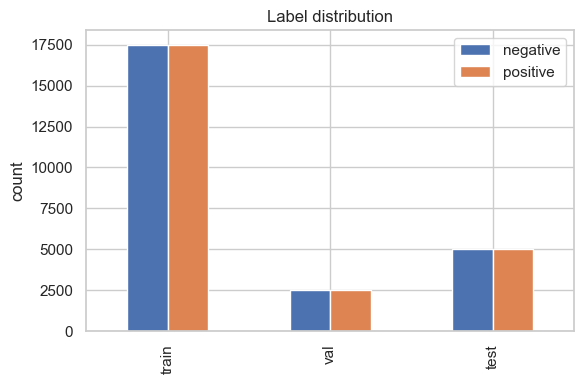

In [4]:
label_df.plot(kind="bar", figsize=(6,4)).set_ylabel("count")
plt.title("Label distribution")
plt.tight_layout()
plt.show()

## 3. Sequence length statistics
Use tokenization prior to building the vocabulary to gauge padding length.

In [5]:
train_lengths = compute_length_stats(train_ds["text"])
val_lengths = compute_length_stats(val_ds["text"])
test_lengths = compute_length_stats(test_ds["text"])

length_df = pd.DataFrame([train_lengths, val_lengths, test_lengths], index=["train", "val", "test"])
length_df

,min,max,mean,p90,count
train,6.0,2473.0,230.493728,449.0,34999.0
val,15.0,1274.0,231.982600,457.1,5000.0
test,8.0,2246.0,232.405559,455.0,10001.0


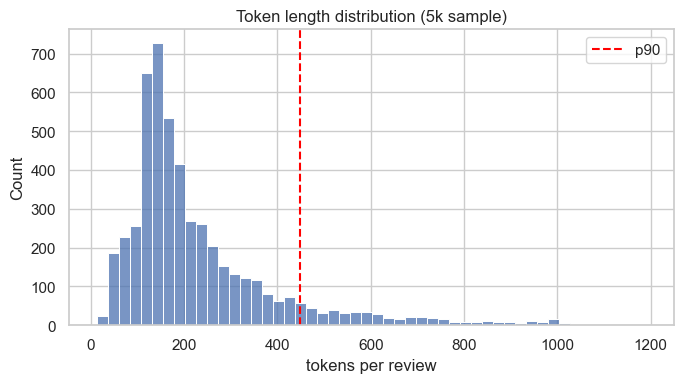

In [6]:
# Histogram of token counts for a subset (to keep plotting quick)
sample_texts = train_ds.select(range(5000))["text"]
lengths = [len(tokenize(clean_text(t))) for t in sample_texts]
plt.figure(figsize=(7,4))
sns.histplot(lengths, bins=50, kde=False)
plt.axvline(train_lengths["p90"], color="red", linestyle="--", label="p90")
plt.xlabel("tokens per review")
plt.title("Token length distribution (5k sample)")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Vocabulary exploration
Build simple frequency counts to inspect the most common tokens. This guides vocabulary sizes (10k/20k/30k) used later.

In [7]:
TOP_K = 30
common_tokens = top_k_frequencies(train_ds.select(range(10000))["text"], k=TOP_K)
pd.DataFrame(common_tokens, columns=["token", "frequency"])

,token,frequency
0,the,133907
1,and,64586
2,a,63823
3,of,57416
4,to,53353
5,is,41944
6,in,37486
7,it,31596
8,i,31235
9,this,30412


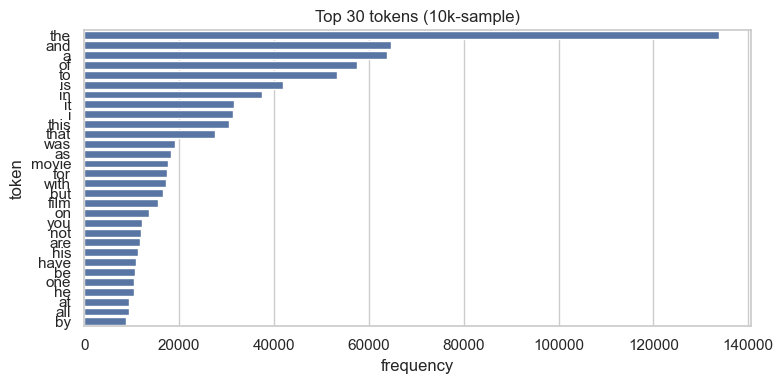

In [8]:
plt.figure(figsize=(8,4))
sns.barplot(x="frequency", y="token", data=pd.DataFrame(common_tokens, columns=["token", "frequency"]))
plt.title(f"Top {TOP_K} tokens (10k-sample)")
plt.tight_layout()
plt.show()

## 5. Sample reviews
Inspect representative positives/negatives after cleaning.

In [9]:
def show_samples(ds, label, n=2):
    rows = [i for i, y in enumerate(ds["label"]) if y == label][:n]
    for idx in rows:
        print("-" * 80)
        print(clean_text(ds[idx]["text"]))
        print()

print("Positive examples")
show_samples(train_ds, label=1)
print("Negative examples")
show_samples(train_ds, label=0)

Positive examples
--------------------------------------------------------------------------------
after some further thought about this film i find it's far too easy to dismiss this as the boy's dream i have actually received some spiritual strength from northfork angels do exist we definitely are entertained by angels most of the time we aren't even aware of it at a point of spiritual and emotional turbidity in my life i personally really needed this film yes as i wrote before it speaks to so many can't wait to get to heaven being so sick of all of the fx and formula stuff i found this film to be genuine cinema all i can say is it touched me in so many ways that i still am sorting it all out north fork is a wonderful film one that brings the viewer's mind out of the gutter and into the heart the spiritual aspect is so very intriguing to me pay attention as you'll need to use the brain and heart god gave you to follow the story i think it's possibly a bit over the heads of some but i 